# Sales Prediction Using Python

## Dataset Overview

The Sales Prediction dataset contains information about advertising expenditure across different media platforms such as TV, Radio, and Newspaper. The objective of this project is to build a Machine Learning model that predicts product sales based on advertising budgets. Initial exploration helps understand the dataset and prepares it for further analysis.

### 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### 2. Load Dataset

In [2]:
df = pd.read_csv("Advertising.csv")

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


### Dataset Overview

The dataset contains advertising expenditure across three different media platforms: TV, Radio, and Newspaper. The target variable is Sales, which represents the sales generated based on advertising investments. The objective is to build a Machine Learning model capable of predicting sales from advertising budgets.

### 3. Dataset Information

In [3]:
df.shape

(200, 5)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [5]:
df.describe()


,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [6]:
df.isnull().sum()

,0
Unnamed: 0,0
TV,0
Radio,0
Newspaper,0
Sales,0


### Observation:

The dataset was inspected to understand the number of records, data types, summary statistics, and missing values. The dataset contains advertising expenditure across different media platforms and the corresponding sales values. No missing values were found, indicating that the dataset is clean and ready for further analysis.

### 4. Data Cleaning

In [7]:
# Remove the unnecessary index column
df = df.drop(columns=['Unnamed: 0'])

# Display the first five rows
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


### Observation:

The dataset contained an additional index column named **'Unnamed: 0'**, which does not contribute to sales prediction. This column was removed to simplify the dataset and improve the model-building process.

### 5. Exploratory Data Analysis (EDA)

### Sales Distribution

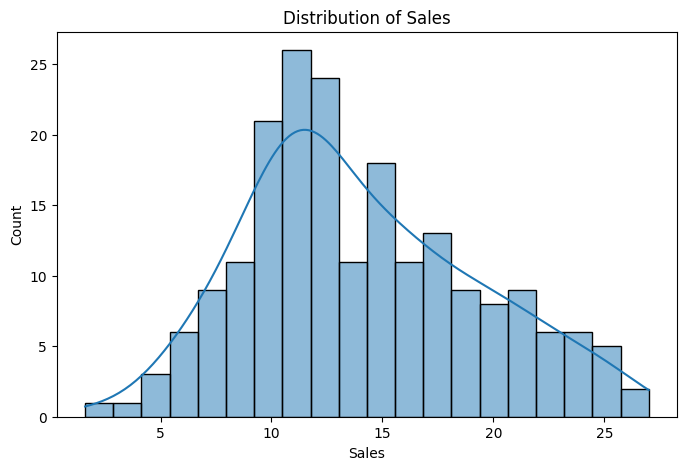

In [8]:
plt.figure(figsize=(8,5))

sns.histplot(df['Sales'], bins=20, kde=True)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Count")

plt.show()

### Observation:

The sales distribution shows that most sales values are concentrated in the middle range, while only a few observations have very high or very low sales values. This indicates that the dataset is fairly balanced for regression analysis.

### Correlation Heatmap

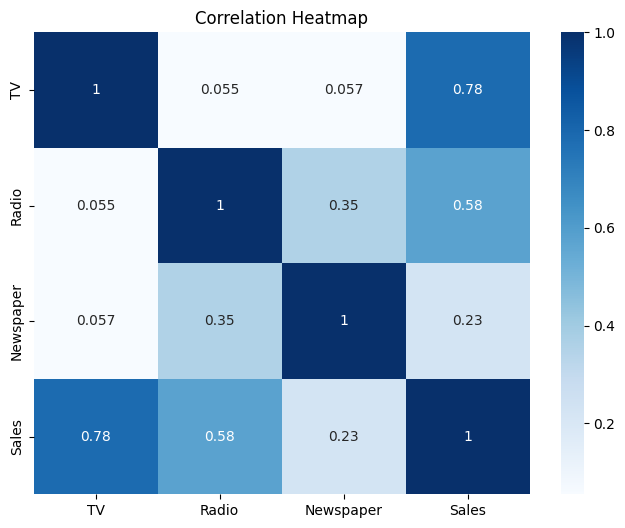

In [9]:
plt.figure(figsize=(8,6))

sns.heatmap(df.corr(), annot=True, cmap="Blues")

plt.title("Correlation Heatmap")

plt.show()

### Observation:

The heatmap shows the relationship between advertising platforms and sales. TV advertising has the strongest positive correlation with sales, followed by Radio. Newspaper advertising has the weakest correlation with sales.

### Pairplot

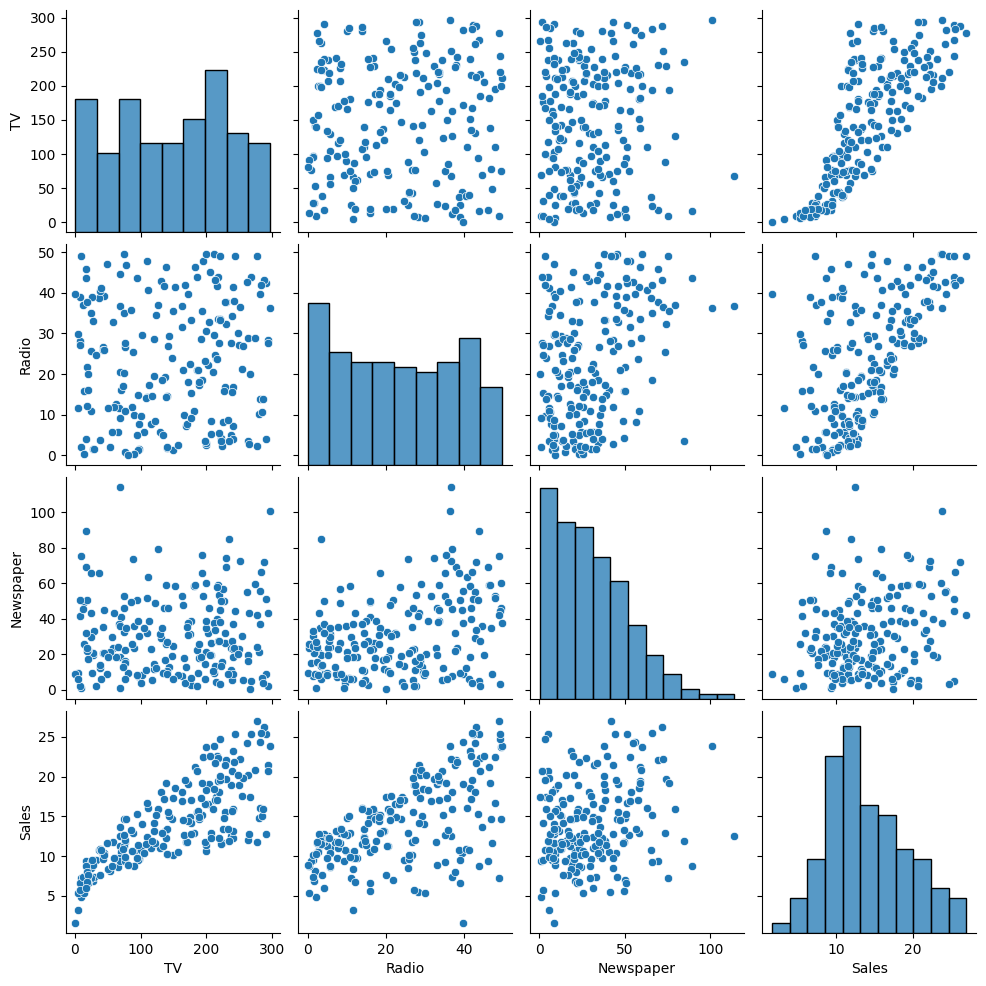

In [10]:
sns.pairplot(df)

plt.show()

### Observation:

The pairplot visualizes the relationship between all numerical variables. It shows that Sales generally increases with higher TV and Radio advertising budgets, while Newspaper advertising shows a weaker relationship with Sales.

### 6. Train-Test Split

In [11]:
X = df.drop("Sales", axis=1)
y = df["Sales"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 160
Testing samples: 40


### Observation:

The dataset was divided into training and testing sets. The training data is used to train the machine learning model, while the testing data is used to evaluate how well the model performs on unseen data.

### 7. Model Training

In [12]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

### Observation:

A Linear Regression model was trained to learn the relationship between advertising expenditure (TV, Radio, and Newspaper) and product sales. The trained model can now predict sales based on advertising budgets.

### 8. Model Evaluation

In [13]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R² Score: 0.899438024100912
MAE: 1.4607567168117603
RMSE: 1.78159966153345


### Observation:

The R² Score indicates how well the model explains the variation in sales. A higher R² Score and lower MAE and RMSE values indicate better prediction performance.

### 9. Actual vs Predicted Sales

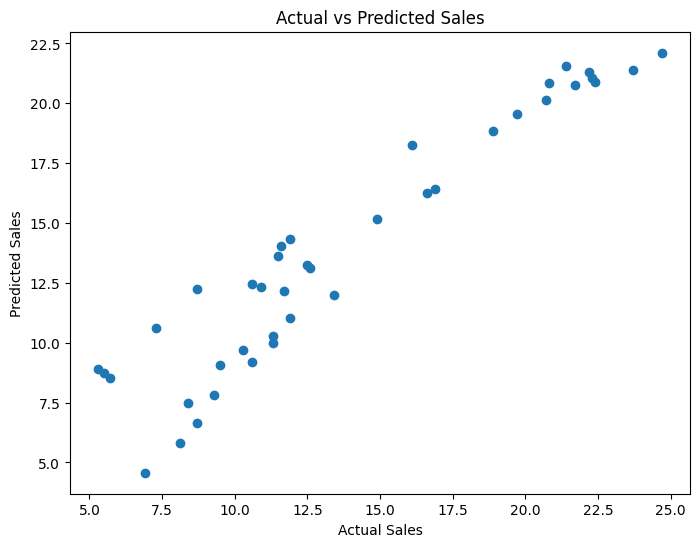

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.show()

### Observation:

The scatter plot compares the actual sales values with the predicted sales values. Most points are closely aligned, indicating that the Linear Regression model predicts sales accurately with only minor deviations.

## Conclusion

In this project, a Linear Regression model was developed to predict product sales based on advertising expenditure across TV, Radio, and Newspaper platforms. Data cleaning and exploratory data analysis were performed to better understand the dataset. The model achieved an **R² Score of approximately 0.90**, demonstrating strong predictive performance. This project highlights how machine learning can be used to estimate product sales and support data-driven marketing decisions.